In [1]:
# !pip install prophet

In [13]:
import pandas as pd
import prophet
from prophet.plot import add_changepoints_to_plot
from prophet import Prophet  # for newer versions


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [15]:
df=pd.read_csv('AirPassengers.csv')

In [16]:
df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [17]:
df1=pd.DataFrame()
df1['ds']=pd.to_datetime(df['Month'])
df1['y']=df['#Passengers']

In [18]:
df1.head()

,ds,y
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [19]:
m = Prophet()
m.fit(df1)

14:08:33 - cmdstanpy - INFO - Chain [1] start processing
14:08:34 - cmdstanpy - INFO - Chain [1] done processing


In [20]:
future=m.make_future_dataframe(periods=12*5,
                              freq='M')

  dates = pd.date_range(


In [21]:
forecast=m.predict(future)

In [22]:
forecast[['ds', 'yhat', 'yhat_lower',
          'yhat_upper', 'trend',
          'trend_lower', 'trend_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper,trend,trend_lower,trend_upper
199,1965-07-31,722.664453,694.752843,753.250093,655.842215,649.254933,662.529079
200,1965-08-31,676.247240,648.156940,704.801968,658.959610,652.157161,665.800731
201,1965-09-30,639.431867,610.059633,669.686206,661.976443,654.995926,668.997480
202,1965-10-31,609.386652,580.598716,640.355303,665.093838,657.903829,672.346909
203,1965-11-30,639.042990,609.937048,669.290550,668.110672,660.722469,675.568558


In [24]:
fig1 = m.plot(forecast, include_legend=True)

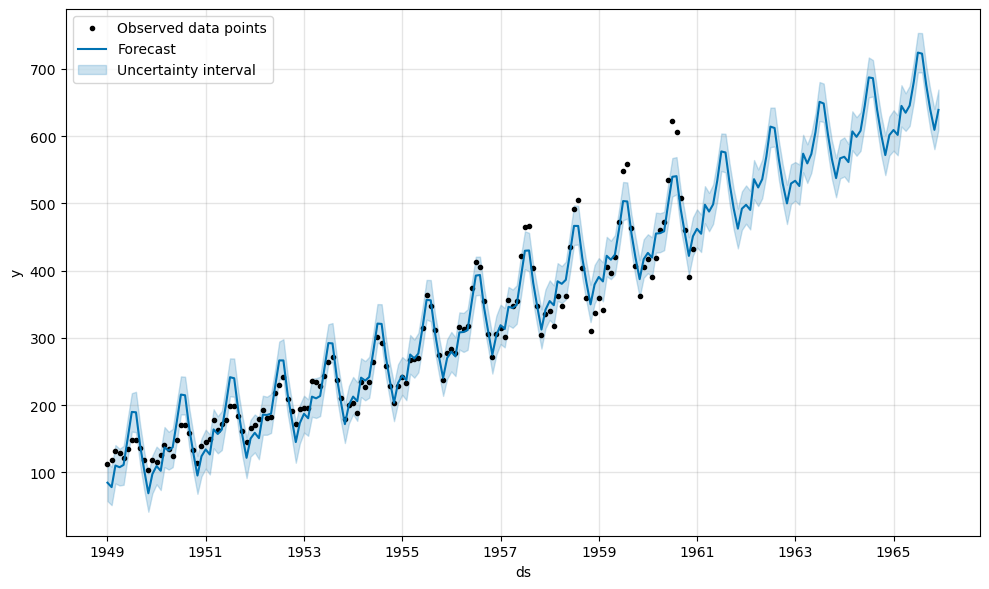

In [25]:
fig1

In [26]:
fig2 = m.plot_components(forecast)

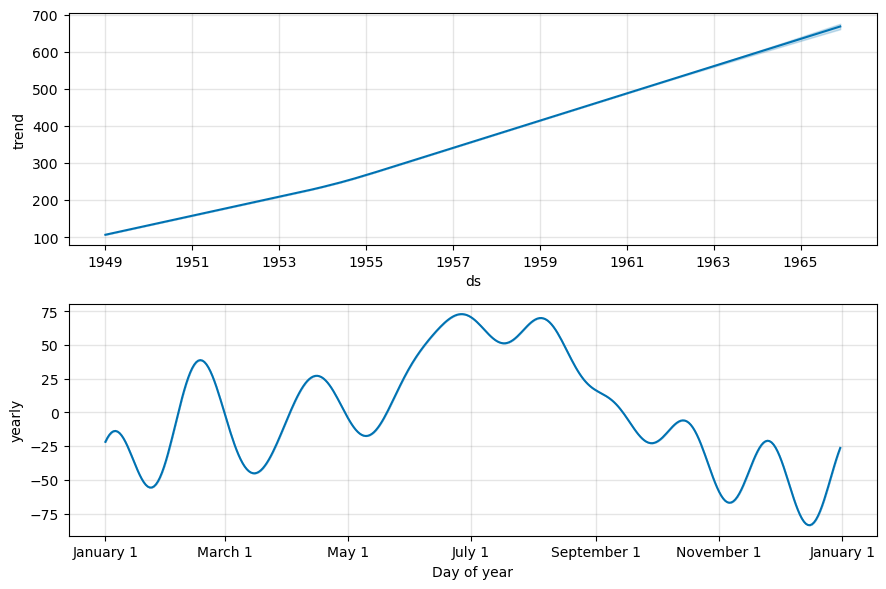

In [27]:
fig2

In [28]:
fig = m.plot(forecast)
a = add_changepoints_to_plot(fig.gca(),
                             m, forecast)

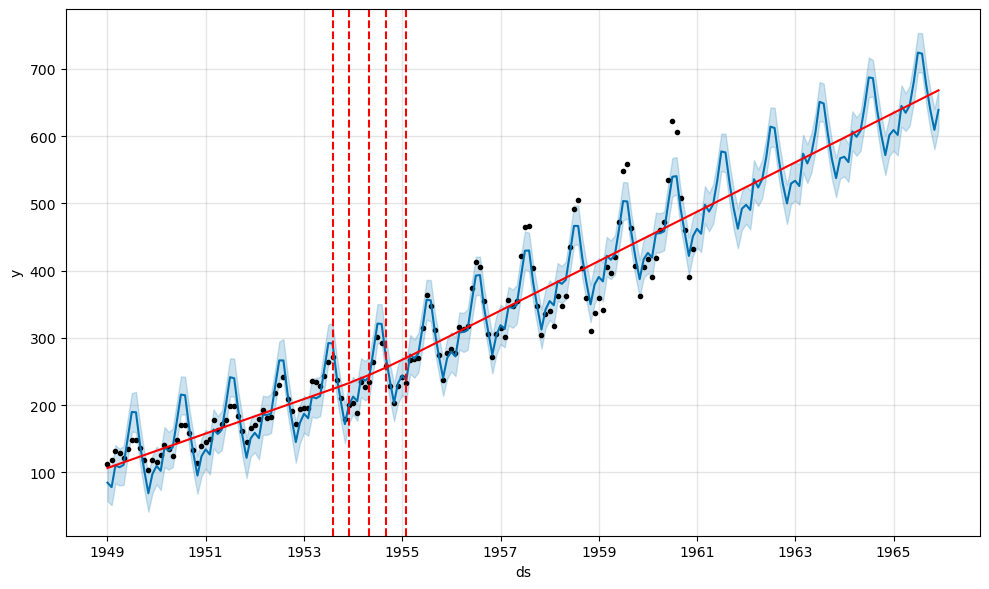

In [30]:
fig